# Predicting Heart disease using Machine Learning

This notebook looks into using various Python-based ML and Data science libraries in a attempt to build a ML model capable of predicting whether or not someone has heart disease based on their medical attributes.

Approach:
    1. Problem Definition
    2. Data
    3. Evaluation
    4. Features 
    5. Modelling 
    6. Experimentation
    
## 1. Problem Definition

In a statement ,
   > Given clinical parameters about a patient , can we predict whether or not they have heart disease?

## 2. Data

The original data came from the Cleavland data from the UCI Machine learning repositry.
https://archive.ics.uci.edu/ml/datasets/Heart+Disease
    
## 3.Evaluation

> If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept , we'll pursue the project.

## 4.Features

**Create data dictionary**

age : age in years
    
sex : (1-male; 0-female)
    
cp : chest pain
    
trestbps : resting blood pressure (in mm Hg on admission to the hospital)
    
chol : serum cholestrol in mg/dl
    
fbs : (fasting blood sugar > 120 mg/dl) (1=true; 0=false)
    
restecg : resting ecg results
    
thalach : max heart rate achieved
    
exang : exercise induced angina (1=yes,0:no)
    
oldpeak : ST depression induced by exercise relative to rest
    
slope : the slope of the peak exercise ST segment
    
ca : number of major vessels (0-3) colored by flourosopy
    
thal : 3-normal,6-fixed defect,7-reversable defect
    
target : 1 or 0
    
### Preparing the tools

We're going to use Pandas, Matplotlib and Numpy for data analysis & manipulation.


In [74]:
# Import all the tools we need

#Regular  EDA(Exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

#To appear the plots inside the notebook
%matplotlib inline 

# Models from scikit learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score
from sklearn.metrics import RocCurveDisplay

## Load Data

In [3]:
df=pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Data Exploration (Exploratory Data Analysis-EDA)

1. What question (s) are you trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

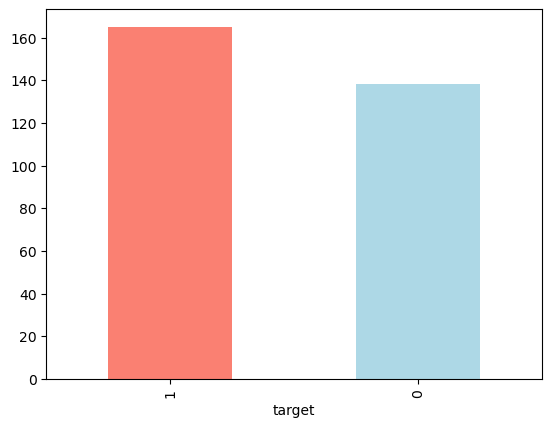

In [7]:
df["target"].value_counts().plot(kind="bar",color=["salmon","lightblue"]);

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# Are there any missing values?
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Heart Disease Frequency according to Sex

In [11]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# Compare target column with sex column
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


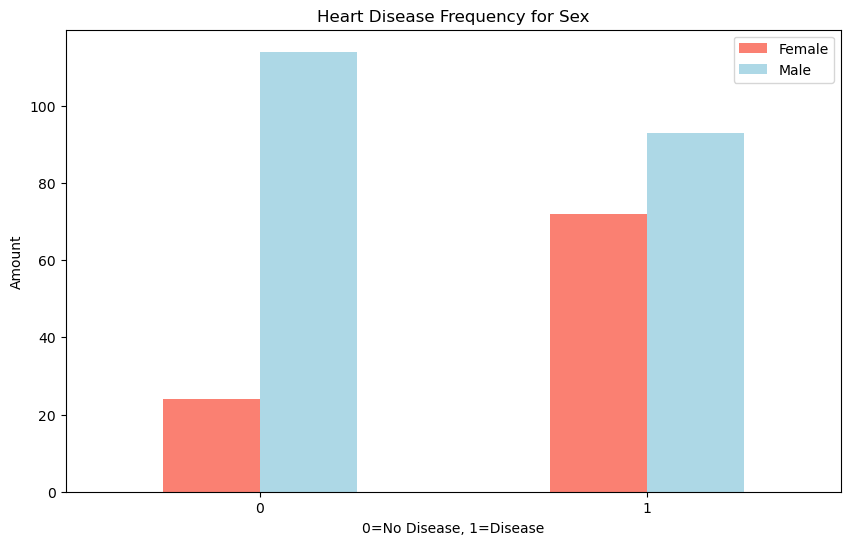

In [13]:
# Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["salmon","lightblue"]);
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0=No Disease, 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"]);
plt.xticks(rotation=0); #This line makes x-axis labels appear Horizontal (not tilted)

### Age vs. Max Heart Rate(thalach) for Heart Disease

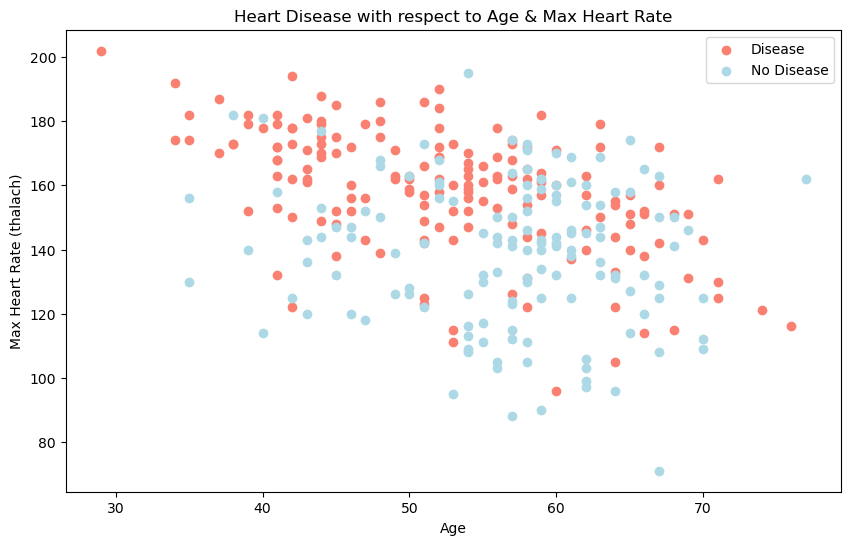

In [14]:
# Create figure
plt.figure(figsize=(10,6))

# Scatter plot with positive examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon");

# Scatter plot with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue");

# Adding Features
plt.title("Heart Disease with respect to Age & Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate (thalach)")
plt.legend(["Disease","No Disease"]);

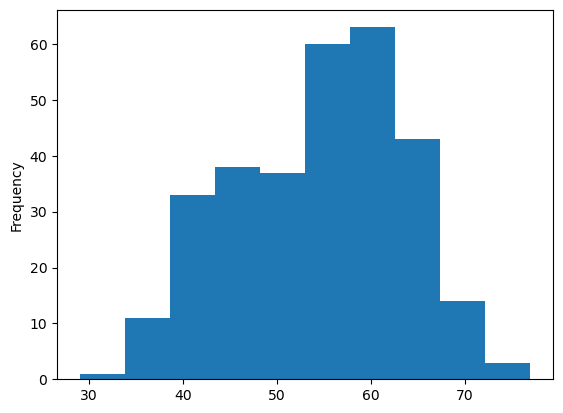

In [15]:
# Check the distribution of the age column with a histogram
df.age.plot.hist();

## Heart Disease Frequency per Chest Pain Type

3. cp- chest pain type
    * 0: Typical angina : chest pain related decrease blood supply to the heart
    * 1: Atypical angina : chest pain not related to heart
    * 2: Non-anginal pain : typically esophageal spasms (non heart related)
    * 3: Asymptomatic : chest pain not showing signs of disease

In [16]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


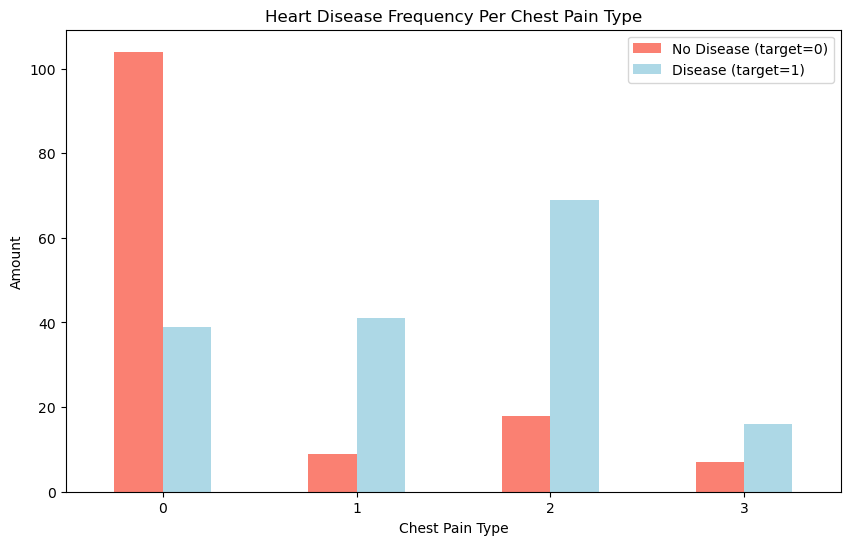

In [17]:
# Making crosstab as visual bar graph
pd.crosstab(df.cp,df.target).plot(kind="bar",
                                  figsize=(10,6),
                                  color=["salmon","lightblue"])
# Adding features
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease (target=0)", "Disease (target=1)"])
plt.xticks(rotation=0);

In [18]:
# Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


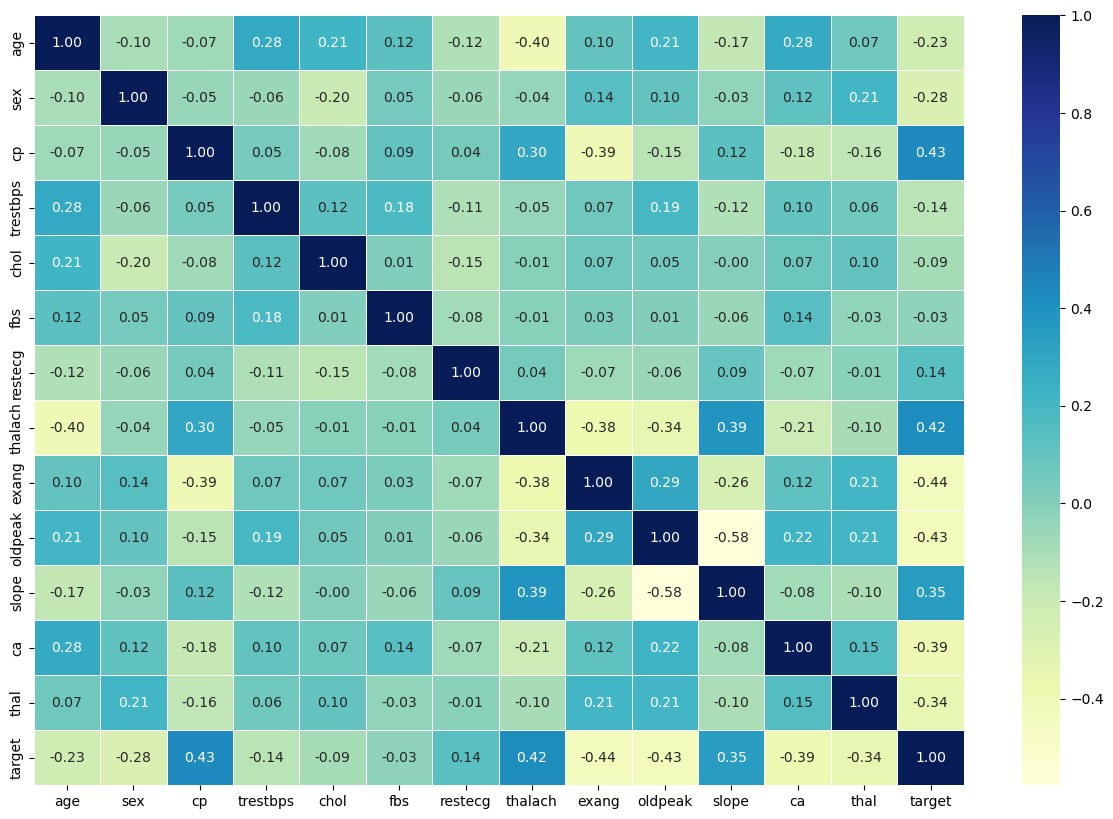

In [19]:
# Making correlation matrix more visual
corr_matrix=df.corr()
fig, ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,
               annot=True,
               linewidth=0.5,
               fmt=".2f",
               cmap="YlGnBu");

## 5. Modelling

In [20]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [21]:
# Split data into x & y
x=df.drop("target", axis=1)
y=df["target"]

In [22]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [23]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [24]:
# Split data into train & test splits
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [25]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [26]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


Now we've got our data split into training and test sets.

We'll train it (find the patterns) on the training set

And we'll test it(use the patterns) on the test set


*We are going to try 3 different machine learning models:*
    
    1. Logistic Regression (A linear model used only for classification prblms even its named regression in it)
    2. K-Nearest Neighbours Classifier
    3. Random Forest Classifier

Note: Rather than using same evaluation metrics for 3 models seperately we set up 
--a little dictionary with our models in it and then we'll create a function to fit & score our models

In [27]:
# Put models in a dictionary
models={"Logistic Regression" : LogisticRegression(),
        "KNN":KNeighborsClassifier(),
        "Random Forest":RandomForestClassifier()}

# Create a function to fit & score models
def fit_and_score(models,x_train,x_test,y_train,y_test):
    """
    Fits and evaluates given machine learning models.
    models: a dict of diff Scikit learn ml models
    x_train : training data-80%( no labels)
    x_test : testing data-20%(no labels)
    y_train : training labels
    y_test : test labels
    """
    # Set random seed
    np.random.seed(42)
    # Make a dictionary to keep model scores
    model_scores={}
    # Loop through models
    for name,model in models.items():
        # Fit the model to data
        model.fit(x_train,y_train)
        # Evaluate the model & append its score to model_scores
        model_scores[name] = model.score(x_test,y_test)
    return model_scores

In [28]:
model_scores=fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)

C:\Users\daraj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## Model Comparision

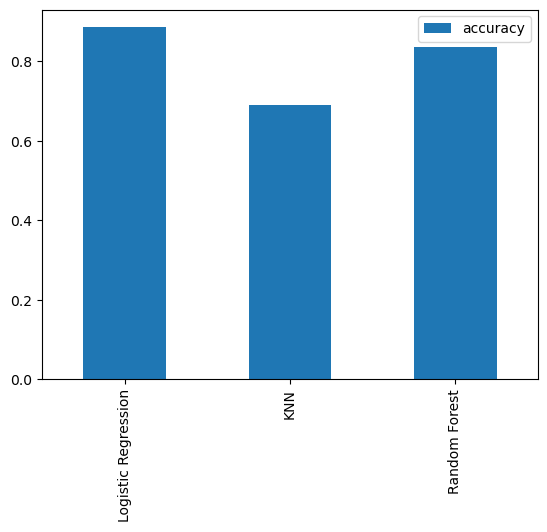

In [30]:
model_compare=pd.DataFrame(model_scores,index=["accuracy"])
model_compare.T.plot.bar();

## Tuning/Improving Our Model

--since the above predictions are only baseline predictions we should improve the results by tuning hyperparameters

Classification & Regression Metrics

*Classification*------------------------------------------*Regression*

1. Accuracy(default)--------------------------------------R^2 (r-squared)
2. Precision----------------------------------------------Mean Absolute Error(MAE)
3. Recall-------------------------------------------------Mean Squared Error(MSE)
4. F1-----------------------------------------------------Root Mean Squared Error(RMSE)

Lets look at the following:

    * Hyperparameter Tuning
    * Feature Importance
    * Confusion Matrix
    * Precision
    * Recall
    * F1 score
    * Classification Report
    * ROC Curve
    * Area under the curve(AUC)

## 1.Hyperparameter Tuning (by Hand)

In [31]:
# Let's tune KNN
train_scores=[]
test_scores=[]

# Create a list of different values for n_neighbors
neighbors= range(1,21)

# Setup KNN Instance
knn = KNeighborsClassifier()

# Here n_neighbors is a model hyperparameter that controls how many neighbors KNN uses, it must be a single integer
# n_neighbors = 5 (default) it indicates that our model looks at the labels of the 5 nearest points and decides the label value based on which value is repeatedly occured.

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    
    # Fit the algorithm
    knn.fit(x_train,y_train)
    
    # Update the training scores list
    train_scores.append(knn.score(x_train,y_train))
    
    # Update the test scores list
    test_scores.append(knn.score(x_test,y_test))

In [32]:
train_scores
# accuracy values of the model on the training set for each n_neighbors value.

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [33]:
test_scores
# accuracy values of the model on the test set for each n_neighbors value.

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Max KNN score on the test data: 75.409836%


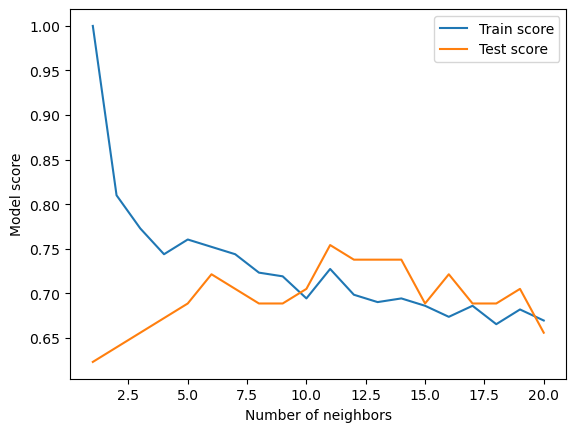

In [34]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
print(f"Max KNN score on the test data: {max(test_scores)*100:2f}%")

Here we only got maximum knn score of 75.4% even after tuning hyperparameters so we use LogisticRegression & RandomForestClassifier models , since their accuracy is pretty high(88.5%,83.6%) even before hyperparameter tuning

## 2.Hyperparameter tuning with RandomizedSearchCV

We're going to tune:

* LogisticRegression()
* RandomForestClassifier()

--using RandomizedSearchCV (which is crossvalidation)

In [35]:
# Create a hyperparameter grid for LogisticRegression()
log_reg_grid = {"C": np.logspace(-4,4,20),
                "solver":["liblinear"]}
'''
*Here C is Regularization Strength---It controls how much the model is allowed to fit the training data.
*np.logspace(-4,4,20) means creating 20 values of C btw 10^-4 to 10^4 spreads logarithmically (Tries many C values from very small to very large)

*solver() defines-- Which algorithm should optimize the model? // ["liblinear"] best for small data sets i.e,. binary classification
'''
# Create a hyperparameter grid for RandomForestClassifier()
rf_grid = {"n_estimators":np.arange(10,1000,50),
           "max_depth":[None,3,5,10],
           "min_samples_split":np.arange(2,20,2),
           "min_samples_leaf":np.arange(1,20,2)
          }
'''
* np.arange(10,1000,50) means start=10 end =1000 & step=50 
* max_depth = the maximum number of levels a decision tree can have(like a Tree data structure)
* min_samples_split = minimum num of samples(rows) needed in a node to allow splitting, if samples are less splitting is not allowed.
* min_samples_leaf = minimum samples required in final leaf nodes
'''


'\n* np.arange(10,1000,50) means start=10 end =1000 & step=50 \n* max_depth = the maximum number of levels a decision tree can have(like a Tree data structure)\n* min_samples_split = minimum num of samples(rows) needed in a node to allow splitting, if samples are less splitting is not allowed.\n* min_samples_leaf = minimum samples required in final leaf nodes\n'

Now we have got hyperparameter grid setup for each of our models , lets tune them using RandomizedSearchCV.

In [36]:
# Tune LogisticRegression 

# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression(i.e.,RandomizedSearchCV)
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                               param_distributions=log_reg_grid,
                               cv=5,
                               n_iter=20,
                               verbose=True)
# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [37]:
# Finding which are the best parameters among them
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [38]:
# Finding model's best score
rs_log_reg.score(x_test,y_test)

0.8852459016393442

In [39]:
# This accuracy is same as previous accuracy i.e., before hyperparameter tuning.

In [40]:
# Tune RandomForestClassifier()

# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier()
rs_rfc=RandomizedSearchCV(RandomForestClassifier(),
                          param_distributions=rf_grid,
                          cv=5,
                          n_iter=20,
                          verbose=True)

# Fit random hyperparameter search for RandomForestClassifier()
rs_rfc.fit(x_train,y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [41]:
# finding best params
rs_rfc.best_params_

{'n_estimators': 210,
 'min_samples_split': 4,
 'min_samples_leaf': 19,
 'max_depth': 3}

In [42]:
# Finding model score for randomized search RandomForestClassifier() model
rs_rfc.score(x_test,y_test)

0.8688524590163934

Here accuracy improved to 86.88% in RandomForestClassifier() (Before tuning it is 83.6%)

In [43]:
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## 3. Hyperparameter Tuning with GridSearchCV

Tuning LogisticRegression() model with GridSearchCV

In [44]:
log_reg_grid={"C":np.logspace(-4,4,30),
              "solver":["liblinear"]}
# Setup grid hyperparam search for LogisticRegression
gs_log_reg=GridSearchCV(LogisticRegression(),
                        param_grid=log_reg_grid,
                        cv=5,
                        verbose=True)

# Fitting
gs_log_reg.fit(x_train,y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [45]:
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [46]:
# Evaluate
gs_log_reg.score(x_test,y_test)
# same result as before

0.8852459016393442

### Evaluating our tuned ml classifier, beyond accuracy

* ROC curve & AUC score
* Confusion matrix
* Classification Report
* Precision
* Recall
* F1 score

...and it would be great if cross-validation was used where possible.

Note: To make comparisions and evaluate our trained model, first we need to make predictions.

In [47]:
# Make predictions with tuned model
y_preds=gs_log_reg.predict(x_test)

In [48]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [49]:
y_pred_proba=gs_log_reg.predict_proba(x_test)[:,1]
y_pred_proba

array([0.13274726, 0.75591495, 0.81452422, 0.05469223, 0.88453356,
       0.87070297, 0.60512178, 0.00435981, 0.01376377, 0.56138458,
       0.71720802, 0.11904144, 0.88730101, 0.06005038, 0.9675006 ,
       0.93181123, 0.96404702, 0.09452761, 0.01769764, 0.02646362,
       0.71543138, 0.02727602, 0.14274672, 0.716608  , 0.88198278,
       0.69480591, 0.84234232, 0.69335557, 0.01830938, 0.8778237 ,
       0.0715076 , 0.06684154, 0.01510285, 0.14314492, 0.6022949 ,
       0.12640329, 0.6633502 , 0.85079082, 0.81898324, 0.84121546,
       0.54515819, 0.79250828, 0.7781759 , 0.70538843, 0.83243213,
       0.02112999, 0.73216372, 0.93234387, 0.10276675, 0.06440751,
       0.1347065 , 0.03554557, 0.8044197 , 0.95312793, 0.31714638,
       0.00309601, 0.0873472 , 0.93823574, 0.028138  , 0.01309874,
       0.06291751])

In [50]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

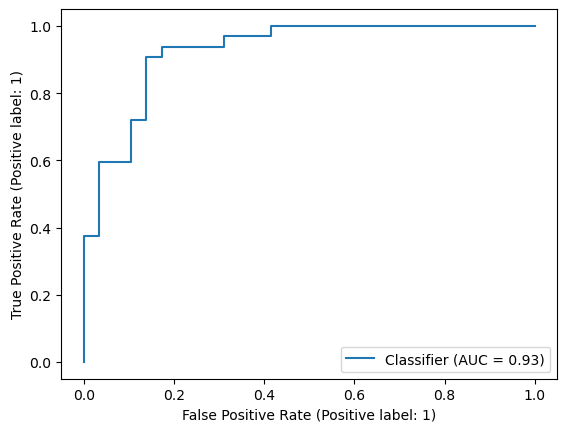

In [51]:
# Plot ROC curve & calculate AUC score
RocCurveDisplay.from_predictions(y_test,y_pred_proba)
# Here we should only use probabilites (i.e.,y_pred_proba) not true values(y_preds)

In [52]:
# Confusion Matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


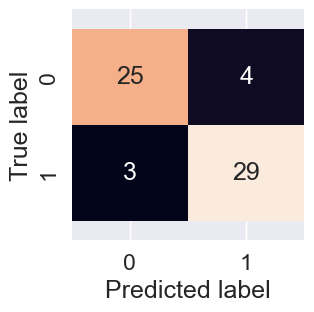

In [53]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),
                   annot=True,
                   cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    # To set the matrix limits without coming out of border 
    bottom,top = ax.get_ylim()
    ax.set_ylim(bottom+0.2, top-0.2)
    
plot_conf_mat(y_test,y_preds)

* classification report
* cv_precision
* recall
* f1-score

In [54]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calculate evaluation metrics using cross-validation

In [55]:
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [56]:
# Create a new classifier with best params
clf=LogisticRegression(C=20433597178569418,
                       solver="liblinear")


In [57]:
# Cross-validated accuracy
cv_acc = cross_val_score(clf,x,y,cv=5,scoring="accuracy")
cv_acc

array([0.80327869, 0.8852459 , 0.83606557, 0.86666667, 0.76666667])

In [58]:
cv_acc = np.mean(cv_acc)
cv_acc

0.831584699453552

In [59]:
# Cross-validated precision
cv_precision = cross_val_score(clf,x,y,cv=5,scoring="precision")
cv_precision

array([0.78378378, 0.90625   , 0.84848485, 0.83783784, 0.74358974])

In [60]:
cv_precision = np.mean(cv_precision)
cv_precision

0.8239892427392427

In [61]:
# Cross-validated recall
cv_recall = cross_val_score(clf,x,y,cv=5,scoring="recall")
cv_recall

array([0.87878788, 0.87878788, 0.84848485, 0.93939394, 0.87878788])

In [62]:
cv_recall = np.mean(cv_recall)
cv_recall

0.8848484848484848

In [63]:
# Cross-validated f1-score
cv_f1 = cross_val_score(clf,x,y,cv=5,scoring="f1")
cv_f1

array([0.82857143, 0.89230769, 0.84848485, 0.88571429, 0.80555556])

In [64]:
cv_f1 = np.mean(cv_f1)
cv_f1

0.8521267621267622

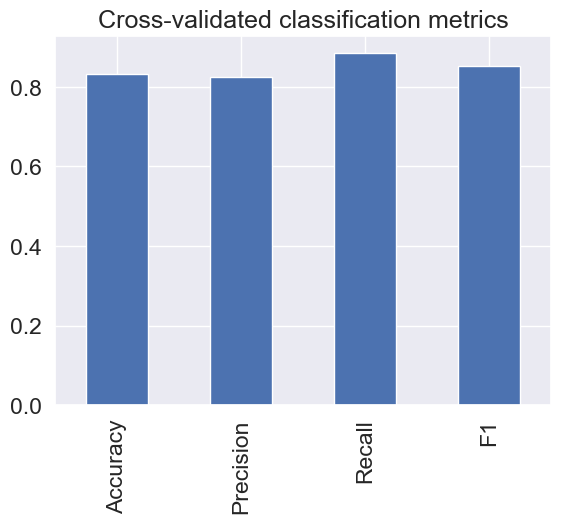

In [65]:
# Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1":cv_f1},
                         index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False);

## Feature Importance

Feature importance is another as asking "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is diff for each ml model.

(in googe) One way to find feature importance is to search for "(MODEL NAME) feature importance"

Let's find the feature importance of LogisticRegression model.

In [66]:
# Fit an instance of LR
clf = LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")
clf.fit(x_train,y_train);

In [67]:
# Check coef_
clf.coef_

array([[ 0.00316728, -0.86044651,  0.66067041, -0.01156993, -0.00166374,
         0.04386107,  0.31275847,  0.02459361, -0.6041308 , -0.56862804,
         0.45051628, -0.63609897, -0.67663373]])

In [68]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [69]:
# Match coef's of features to columns
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': 0.0031672801993431563,
 'sex': -0.8604465072345515,
 'cp': 0.6606704082033799,
 'trestbps': -0.01156993168080875,
 'chol': -0.001663744504776871,
 'fbs': 0.043861071652469864,
 'restecg': 0.31275846822418324,
 'thalach': 0.024593613737779126,
 'exang': -0.6041308000615746,
 'oldpeak': -0.5686280368396555,
 'slope': 0.4505162797258308,
 'ca': -0.6360989676086223,
 'thal': -0.6766337263029825}

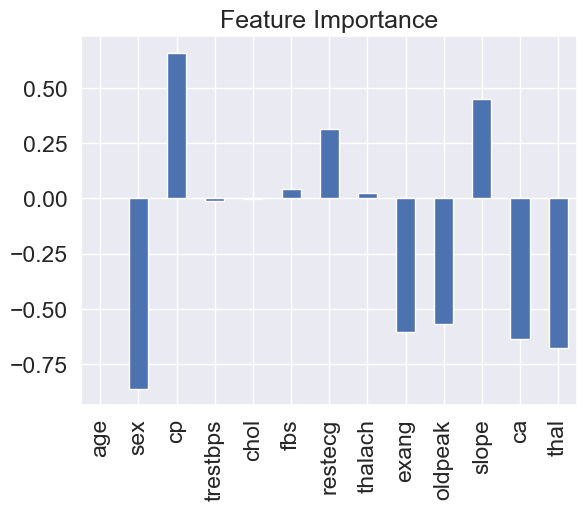

In [70]:
# Visualize feature importance
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance", legend=False);

In [71]:
pd.crosstab(df["sex"],df["target"])
# This having negative correlation

target,0,1
sex,,
0,24,72
1,114,93


In [72]:
pd.crosstab(df["slope"],df["target"])

# This having positive correlation

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


## 6. Experimentation

If you haven't hit your evaluation metric yet...ask yourself..

* Could you collect more data?
* Could you try a better model? # like CatBoost or XGBoost?
* Could you improve the current models?
* If your model is good enough (met eval metric) how would you export or share it?


## 7. Saving the model

In [77]:
with open("clf.pkl","wb") as file:
    pickle.dump(clf,file)